In [33]:
#DATA COLLECTION
from sklearn.datasets import load_breast_cancer
import pandas as pd

data=load_breast_cancer()
df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target
x=df.drop('target',axis=1)
y=df['target']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [41]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split as ts
x_train,x_test,y_train,y_test=ts(x,y,test_size=0.2,random_state=42)

In [47]:
#FEATURE SCALING
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
xtrains=scaler.fit_transform(x_train)
xtests=scaler.transform(x_test)

In [79]:
from sklearn.svm import SVC
svm=SVC(kernel='linear',random_state=42)
svm.fit(xtrains,y_train)
y_pred=svm.predict(xtests)

In [81]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.956140350877193
[[41  2]
 [ 3 68]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



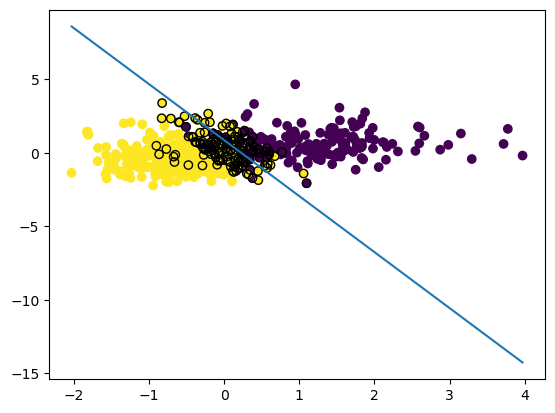

In [95]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC

model = SVC(kernel="linear").fit(X, y)

w = model.coef_[0]
b = model.intercept_[0]

xx = np.linspace(X[:,0].min(), X[:,0].max(), 100)
yy = -(w[0] * xx + b) / w[1]

plt.scatter(X[:,0], X[:,1], c=y)
plt.plot(xx, yy)
plt.scatter(model.support_vectors_[:,0],
            model.support_vectors_[:,1],
            facecolors="none", edgecolors="black")

plt.show()

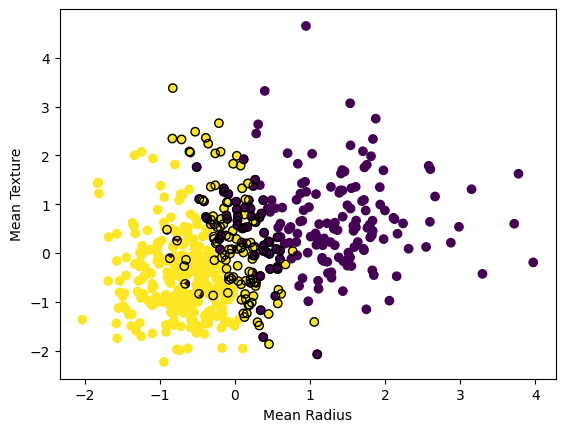

In [97]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X = df[["mean radius", "mean texture"]]
y = df["target"]

X = StandardScaler().fit_transform(X)

model = SVC(kernel="linear")
model.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            facecolors="none", edgecolors="black")

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.show()